In [1]:
import torch
import torch.nn as nn
import numpy as np
from DDBSCAN import Raster_DBSCAN
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim
from Models import *
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.colors as mcolors
from ModelSocial import LaneSocialLSTM
from Dataset import SocialLSTMDataset,social_lstm_collate
import h5py

# from TrainSocialLSTM import extract_trajectories,prepare_training_data
# times new roman font
plt.rcParams["font.family"] = "Times New Roman"
seed = 414
# np.random.seed(seed)
colors = np.random.rand(600, 3)
colors = np.concatenate([np.array([[0,0,0]]),colors],axis = 0)
colormap = mcolors.ListedColormap(colors)

In [2]:
import os
import numpy as np
import h5py
from tqdm import tqdm
import random
import glob

def process_traffic_context_data(
    source_dir,
    output_dir,
    input_frames=10,
    output_frames=12,
    train_samples=10000,
    val_samples=2000,
    seed=42
):
    """
    Process large traffic context data into smaller clips for Social-LSTM training
    
    Args:
        source_dir: Directory containing the original traffic context data
        output_dir: Directory to save processed data
        input_frames: Number of input frames per clip
        output_frames: Number of output frames per clip
        train_samples: Number of training samples to generate
        val_samples: Number of validation samples to generate
        seed: Random seed for reproducibility
    """
    # Set random seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    
    # Create output directories
    train_dir = os.path.join(output_dir, 'train')
    val_dir = os.path.join(output_dir, 'val')
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    
    # Get list of traj_id files
    traj_id_files = glob.glob(os.path.join(source_dir, 'traj_id_label', '*.npy'))
    
    # Create H5PY files for training and validation
    train_h5_path = os.path.join(train_dir, 'social_lstm_data.h5')
    val_h5_path = os.path.join(val_dir, 'social_lstm_data.h5')
    print(f"Creating HDF5 files at {train_h5_path} and {val_h5_path}")
    with h5py.File(train_h5_path, 'w') as train_h5, h5py.File(val_h5_path, 'w') as val_h5:
        # Create datasets with maxshape parameter to allow resizing
        train_h5.create_dataset('traffic_context', # occupancy data
                              shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip",
                              compression_opts=4)
        
        train_h5.create_dataset('vehicle_id',
                                shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip",
                              compression_opts=4)
        
        train_h5.create_dataset('speed_data', 
                              shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip", 
                              compression_opts=4)
        train_h5.create_dataset('metadata', 
                              shape=(train_samples, 3),  # [file_idx, start_frame, num_vehicles]
                              maxshape=(None, 3), # Allow resizing
                              dtype=np.int32,
                              chunks=(100, 3))
        # Create same datasets for validation
        val_h5.create_dataset('traffic_context', 
                            shape=(val_samples, 200, input_frames + output_frames),
                            maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                            dtype=np.float32,
                            chunks=(1, 200, input_frames + output_frames),
                            compression="gzip",
                            compression_opts=4)
        val_h5.create_dataset('vehicle_id',
                                shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip",
                              compression_opts=4)
        val_h5.create_dataset('speed_data', 
                            shape=(val_samples, 200, input_frames + output_frames),
                            maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                            dtype=np.float32,
                            chunks=(1, 200, input_frames + output_frames),
                            compression="gzip",
                            compression_opts=4)
        val_h5.create_dataset('metadata', 
                            shape=(val_samples, 3),  # [file_idx, start_frame, num_vehicles]
                            maxshape=(None, 3), # Allow resizing
                            dtype=np.int32,
                            chunks=(100, 3))
        
        # Store source file names for reference
        train_h5.create_dataset('file_names', 
                              shape=(len(traj_id_files),),
                              dtype=h5py.special_dtype(vlen=str))
        val_h5.create_dataset('file_names', 
                            shape=(len(traj_id_files),),
                            dtype=h5py.special_dtype(vlen=str))
        
        for i, file_path in enumerate(traj_id_files):
            train_h5['file_names'][i] = os.path.basename(file_path)
            val_h5['file_names'][i] = os.path.basename(file_path)
        
        # Sample counter
        train_count = 0
        val_count = 0
        print( len(traj_id_files),'aa' )
        # Process each file and generate samples
        for file_idx, file_path in enumerate(tqdm(traj_id_files, desc="Processing files")):
            # Load trajectory ID data
            traj_id_data = np.load(file_path)
            
            # Try to load speed data if available
            try:
                speed_path = file_path.replace('traj_id_label', 'speed_label')
                speed_data = np.load(speed_path)
            except:
                # Create dummy speed data if not available
                speed_data = np.zeros_like(traj_id_data)
            try:
                occupancy_path = file_path.replace('traj_id_label', 'post_occ_label')
                occupancy_data = np.load(occupancy_path)
            except:
                # Create dummy occupancy data if not available
                occupancy_data = np.zeros_like(traj_id_data)
            
            # Get file shape
            lane_cells, time_span = traj_id_data.shape # 200, 100
            
            # Calculate number of possible starting frames
            max_start = time_span - (input_frames + output_frames) + 1
            
            if max_start <= 0:
                print(f"Skipping {file_path} - not enough frames")
                continue
            
            # Generate potential starting frames
            start_frames = list(range(0, max_start))
            random.shuffle(start_frames)
            
            # Select samples for this file
            file_train_count = min(100, len(start_frames) // 2)  # Limit samples per file
            file_val_count = min(20, len(start_frames) // 10)  # Limit validation samples per file
            # Generate training samples
            for i, start_frame in enumerate(start_frames[:file_train_count]):
                if train_count >= train_samples:
                    break
                    
                # Extract clip
                traj_id_clip = traj_id_data[:, start_frame:start_frame + input_frames + output_frames]
                occupancy_clip = occupancy_data[:, start_frame:start_frame + input_frames + output_frames]
                speed_clip = speed_data[:, start_frame:start_frame + input_frames + output_frames]
                
                # Count unique vehicles (excluding 0)
                unique_vehicles = np.unique(traj_id_clip)
                num_vehicles = len(unique_vehicles[unique_vehicles > 0])
                
                # Skip if no vehicles
                if num_vehicles == 0:
                    continue
                
                # Store data
                train_h5['vehicle_id'][train_count] = traj_id_clip
                train_h5['traffic_context'][train_count] = occupancy_clip
                train_h5['speed_data'][train_count] = speed_clip
                train_h5['metadata'][train_count] = [file_idx, start_frame, num_vehicles]
                
                train_count += 1
                
                # Print progress
                if train_count % 1000 == 0:
                    print(f"Generated {train_count}/{train_samples} training samples")
            
            # Generate validation samples
            for i, start_frame in enumerate(start_frames[file_train_count:file_train_count + file_val_count]):
                if val_count >= val_samples:
                    break
                    
                # Extract clip
                traj_id_clip = traj_id_data[:, start_frame:start_frame + input_frames + output_frames]
                occupancy_clip = occupancy_data[:, start_frame:start_frame + input_frames + output_frames]
                speed_clip = speed_data[:, start_frame:start_frame + input_frames + output_frames]
                
                # Count unique vehicles (excluding 0)
                unique_vehicles = np.unique(traj_id_clip)
                num_vehicles = len(unique_vehicles[unique_vehicles > 0])
                
                # Skip if no vehicles
                if num_vehicles == 0:
                    continue
                
                # Store data
                val_h5['vehicle_id'][val_count] = traj_id_clip
                val_h5['traffic_context'][val_count] = occupancy_clip
                val_h5['speed_data'][val_count] = speed_clip
                val_h5['metadata'][val_count] = [file_idx, start_frame, num_vehicles]
                
                val_count += 1
                
                # Print progress
                if val_count % 500 == 0:
                    print(f"Generated {val_count}/{val_samples} validation samples")
            
            # Break if we have enough samples
            if train_count >= train_samples and val_count >= val_samples:
                break
        
        # Update dataset sizes if we didn't generate enough samples
        if train_count < train_samples:
            print(f"Only generated {train_count}/{train_samples} training samples")
            train_h5['vehicle_id'].resize((train_count, 200, input_frames + output_frames))
            train_h5['traffic_context'].resize((train_count, 200, input_frames + output_frames))
            train_h5['speed_data'].resize((train_count, 200, input_frames + output_frames))
            train_h5['metadata'].resize((train_count, 3))
        
        if val_count < val_samples:
            print(f"Only generated {val_count}/{val_samples} validation samples")
            val_h5['vehicle_id'].resize((val_count, 200, input_frames + output_frames))
            val_h5['traffic_context'].resize((val_count, 200, input_frames + output_frames))
            val_h5['speed_data'].resize((val_count, 200, input_frames + output_frames))
            val_h5['metadata'].resize((val_count, 3))
    
    print(f"Successfully processed data:")
    print(f"  - Training samples: {train_count}")
    print(f"  - Validation samples: {val_count}")
    print(f"  - Saved to: {output_dir}")

    return train_h5_path, val_h5_path

In [ ]:
source_dir=r'D:\TimeSpaceDiagramDataset\EncoderDecoder_EvenlySampled_FreeflowAug_0914_5res_lanechange_signal\100_frame\train'
output_dir=r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\dataset'
input_frames=10
output_frames=1
train_samples=20000
val_samples=4000
seed=714
process_traffic_context_data(source_dir, output_dir, input_frames, output_frames, train_samples, val_samples, seed)

In [ ]:
class TrafficContextDataset(torch.utils.data.Dataset):
    def __init__(self, h5_path, input_frames=10, output_frames=12, max_vehicles=10):
        """
        Dataset for training Social-LSTM on traffic context data
        
        Args:
            h5_path: Path to the HDF5 file containing traffic context data
            input_frames: Number of input frames
            output_frames: Number of output frames
            max_vehicles: Maximum number of vehicles to consider per sample
        """
        self.h5_path = h5_path
        self.input_frames = input_frames
        self.output_frames = output_frames
        self.max_vehicles = max_vehicles
        
        # Get dataset shapes without keeping the file open
        with h5py.File(h5_path, 'r') as f:
            self.num_samples = f['traffic_context'].shape[0]
            self.lane_cells = f['traffic_context'].shape[1]
            self.total_frames = f['traffic_context'].shape[2]
        
        print(f"Loaded dataset with {self.num_samples} samples, {self.lane_cells} lane cells, {self.total_frames} frames")
    
    def __len__(self):
        return self.num_samples
    
    def extract_vehicle_trajectories(self, vehicle_id_data):
        """
        Extract individual vehicle trajectories from vehicle_id data
        
        Args:
            vehicle_id_data: Vehicle ID data [lane_cells, total_frames]
            
        Returns:
            trajectories: Dict mapping vehicle_id to position time series
            vehicle_ids: List of vehicle IDs in this sample
        """
        vehicle_ids = set()
        trajectories = {}
        
        # Find all vehicle IDs (excluding -1)
        for t in range(self.total_frames):
            ids = np.unique(vehicle_id_data[:, t])
            for vid in ids:
                if vid >= 0:  # Skip empty cells (-1)
                    vehicle_ids.add(int(vid))
        
        # Extract trajectories for each vehicle
        for vid in vehicle_ids:
            trajectory = np.zeros(self.total_frames)
            for t in range(self.total_frames):
                # Find positions where this vehicle ID appears
                positions = np.where(vehicle_id_data[:, t] == vid)[0]
                if len(positions) > 0:
                    # Use the front position (smallest index)
                    trajectory[t] = np.min(positions)
                else:
                    # Vehicle not present in this frame
                    trajectory[t] = -1
            
            trajectories[vid] = trajectory
        
        # Convert set to list and sort
        vehicle_ids = sorted(list(vehicle_ids))
        
        return trajectories, vehicle_ids
    
    def get_social_context(self, vid, frame_idx, trajectories, vehicle_ids, traffic_context):
        """
        Get social context for a vehicle at a specific frame
        
        Args:
            vid: Vehicle ID
            frame_idx: Frame index
            trajectories: Dict mapping vehicle_id to position time series
            vehicle_ids: List of vehicle IDs
            traffic_context: Traffic context data [lane_cells, total_frames]
            
        Returns:
            front_vehicle: [distance to front vehicle, presence flag]
            back_vehicle: [distance to back vehicle, presence flag]
        """
        # Get current vehicle position
        current_pos = trajectories[vid][frame_idx]
        if current_pos < 0:
            # Vehicle not present in this frame
            return [0.0, 0.0], [0.0, 0.0]
        
        # Find front vehicle
        front_distance = float('inf')
        front_presence = 0.0
        
        # Find back vehicle
        back_distance = float('inf')
        back_presence = 0.0
        
        # Check all other vehicles
        for other_vid in vehicle_ids:
            if other_vid == vid:
                continue
            
            other_pos = trajectories[other_vid][frame_idx]
            if other_pos < 0:
                # Other vehicle not present in this frame
                continue
            
            # Check if other vehicle is in front
            if other_pos < current_pos:  # Front has smaller index
                distance = current_pos - other_pos
                if distance < front_distance:
                    front_distance = distance
                    front_presence = 1.0
            
            # Check if other vehicle is behind
            elif other_pos > current_pos:
                distance = other_pos - current_pos
                if distance < back_distance:
                    back_distance = distance
                    back_presence = 1.0
        
        # Normalize distances
        if front_presence > 0:
            front_distance = min(front_distance / 50.0, 1.0)  # Normalize to [0, 1]
        else:
            front_distance = 0.0
            
        if back_presence > 0:
            back_distance = min(back_distance / 50.0, 1.0)  # Normalize to [0, 1]
        else:
            back_distance = 0.0
        
        return [front_distance, front_presence], [back_distance, back_presence]
    
    def __getitem__(self, idx):
        """
        Get a sample from the dataset
        
        Returns:
            inputs: Dict containing:
                - 'vehicle_positions': Tensor [num_vehicles, input_frames]
                - 'front_context': Tensor [num_vehicles, input_frames, 2]
                - 'back_context': Tensor [num_vehicles, input_frames, 2]
                - 'traffic_context': Tensor [input_frames, lane_cells]
            targets: Tensor [num_vehicles, output_frames]
        """
        # Load data for this sample
        vehicle_id_data = self.h5_file['vehicle_id'][idx]
        traffic_context_data = self.h5_file['traffic_context'][idx]
        
        # Extract vehicle trajectories
        trajectories, vehicle_ids = self.extract_vehicle_trajectories(vehicle_id_data)
        
        # Limit number of vehicles if needed
        if len(vehicle_ids) > self.max_vehicles:
            vehicle_ids = vehicle_ids[:self.max_vehicles]
        
        # Prepare tensors
        num_vehicles = len(vehicle_ids)
        vehicle_positions = np.zeros((num_vehicles, self.input_frames))
        front_context = np.zeros((num_vehicles, self.input_frames, 2))
        back_context = np.zeros((num_vehicles, self.input_frames, 2))
        targets = np.zeros((num_vehicles, self.output_frames))
        
        # Extract data for each vehicle
        for i, vid in enumerate(vehicle_ids):
            trajectory = trajectories[vid]
            
            # Extract input positions
            vehicle_positions[i] = trajectory[:self.input_frames]
            
            # Extract target positions
            targets[i] = trajectory[self.input_frames:self.input_frames + self.output_frames]
            
            # Extract social context for each input frame
            for t in range(self.input_frames):
                front_context[i, t], back_context[i, t] = self.get_social_context(
                    vid, t, trajectories, vehicle_ids, traffic_context_data
                )
        
        # Extract traffic context data
        traffic_context = traffic_context_data[:, :self.input_frames].T  # [input_frames, lane_cells]
        
        # Convert to tensors
        inputs = {
            'vehicle_positions': torch.FloatTensor(vehicle_positions),
            'front_context': torch.FloatTensor(front_context),
            'back_context': torch.FloatTensor(back_context),
            'traffic_context': torch.FloatTensor(traffic_context),
            'vehicle_ids': torch.LongTensor(vehicle_ids),
        }
        targets = torch.FloatTensor(targets)
        
        return inputs, targets
    
    def close(self):
        """Close the HDF5 file"""
        self.h5_file.close()
        
def collate_variable_fn(batch):
    """
    Collate function for batching samples with variable numbers of vehicles
    
    Args:
        batch: List of (inputs, targets) tuples
        
    Returns:
        inputs_batch: Dict of batched inputs
        targets_batch: Batched targets
    """
    # Find max number of vehicles in this batch
    max_vehicles = max(inputs['vehicle_positions'].size(0) for inputs, _ in batch)
    
    # Prepare batched tensors
    batch_size = len(batch)
    
    # Initialize with zeros
    vehicle_positions_batch = torch.zeros(batch_size, max_vehicles, batch[0][0]['vehicle_positions'].size(1))
    front_context_batch = torch.zeros(batch_size, max_vehicles, batch[0][0]['front_context'].size(1), 2)
    back_context_batch = torch.zeros(batch_size, max_vehicles, batch[0][0]['back_context'].size(1), 2)
    traffic_context_batch = torch.zeros(batch_size, batch[0][0]['traffic_context'].size(0), 
                                        batch[0][0]['traffic_context'].size(1))
    vehicle_ids_batch = torch.zeros(batch_size, max_vehicles, dtype=torch.long)
    targets_batch = torch.zeros(batch_size, max_vehicles, batch[0][1].size(1))
    
    # Fill batched tensors
    for i, (inputs, targets) in enumerate(batch):
        num_vehicles = inputs['vehicle_positions'].size(0)
        
        vehicle_positions_batch[i, :num_vehicles] = inputs['vehicle_positions']
        front_context_batch[i, :num_vehicles] = inputs['front_context']
        back_context_batch[i, :num_vehicles] = inputs['back_context']
        traffic_context_batch[i] = inputs['traffic_context']
        vehicle_ids_batch[i, :num_vehicles] = inputs['vehicle_ids']
        targets_batch[i, :num_vehicles] = targets
    
    # Create batched inputs dictionary
    inputs_batch = {
        'vehicle_positions': vehicle_positions_batch,
        'front_context': front_context_batch,
        'back_context': back_context_batch,
        'traffic_context': traffic_context_batch,
        'vehicle_ids': vehicle_ids_batch,
    }
    
    return inputs_batch, targets_batch

In [31]:
val_h5_path = r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\dataset\val\social_lstm_data.h5'
val_dataset = TrafficContextDataset(
    h5_path=val_h5_path,
    input_frames=10,
    output_frames=1
)
val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_variable_fn,
    # num_workers=1
)

Loaded dataset with 4000 samples, 200 lane cells, 11 frames


In [35]:
for batch in val_loader:
    inputs, targets = batch
    vehicle_positions = inputs['vehicle_positions']
    front_context = inputs['front_context']
    back_context = inputs['back_context']
    
    break  # Remove this to process all batches

In [41]:
vehicle_positions.shape

torch.Size([4, 4, 10])

In [19]:
target_context.shape

torch.Size([32, 200, 1])

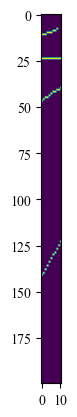

In [22]:
plt.imshow(traffic_context[4].cpu().numpy())
plt.show()